# Assignment 2: Transfer Learning Across Two Datasets

**Name:** Alexander Sturgill

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [2]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: alexandersturgill
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:06<00:00, 65.1MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [3]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.


In [9]:
# Your exploration here
fire_dir = os.path.join(data_dir_fire, "fire_images")
non_fire_dir = os.path.join(data_dir_fire, "non_fire_images")

fire_count = len(os.listdir(fire_dir))
non_fire_count = len(os.listdir(non_fire_dir))
total_count = fire_count + non_fire_count

print(f"Fire images:     {fire_count} ({fire_count / total_count:.1%})")
print(f"Non-fire images: {non_fire_count} ({non_fire_count / total_count:.1%})")


Fire images:     755 (75.6%)
Non-fire images: 244 (24.4%)


*What did you notice about this dataset? Does it change how you'll approach the next steps?*

A: The Fire Images Class has 755 images, which makes up 75.6% of all the images whereas the Non-fire Images Class has 244 images, which makes up only 24.4% of all the images. This indicates a serious imbalance of the amount of images between the two classes. Since already ~75% of our images indicate fire, we should be wary of the accuracy of our model prediction an ensure it doesn't attempt to follow this imbalance which will skew our results. In order to help preserve the percentages in our train and test sets, we'll used a Stratified-Train-Test-Split in order to ensure that the same percentage of each class is in the Train and Test Sets


## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [11]:
# Preprocess the data here

train_fire = train_raw_fire.map(lambda x, y: (preprocess_input(x), y))
val_fire = val_raw_fire.map(lambda x, y: (preprocess_input(x), y))
test_fire = test_raw_fire.map(lambda x, y: (preprocess_input(x), y))

autotune = tf.data.AUTOTUNE
train_fire = train_fire.prefetch(buffer_size=autotune)
val_fire = val_fire.prefetch(buffer_size=autotune)
test_fire = test_fire.prefetch(buffer_size=autotune)

In [13]:
# Build your model here

base_model_fire = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

base_model_fire.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model_fire(inputs, training=False)  # Ensure batch norm runs in inference mode
x = GlobalAveragePooling2D()(x)
outputs = Dense(1, activation="sigmoid")(x)  # Binary output (0 or 1)

model_fire = Model(inputs, outputs)

In [14]:
# Compile your model here

model_fire.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model_fire.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 1D — Train and Evaluate

In [15]:
# Train your model here

history_fire = model_fire.fit(
    train_fire,
    validation_data=val_fire,
    epochs=10,
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.8100 - loss: 0.3722 - val_accuracy: 0.9353 - val_loss: 0.2279
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.9471 - loss: 0.1554 - val_accuracy: 0.9640 - val_loss: 0.1350
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9714 - loss: 0.1043 - val_accuracy: 0.9640 - val_loss: 0.0985
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.9786 - loss: 0.0845 - val_accuracy: 0.9712 - val_loss: 0.0792
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.9871 - loss: 0.0720 - val_accuracy: 0.9712 - val_loss: 0.0792
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.9929 - loss: 0.0635 - val_accuracy: 0.9640 - val_loss: 0.0886
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9943 - loss: 0.0566 - val_accuracy: 0.9568 - val_loss: 0.0904
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.9943 - loss: 0.0521 - val_accuracy: 0.9640 - val_loss:

In [17]:
# Report validation and test accuracy here

# The Validation Accuracy after 10 Epochs is 0.9568 and the Test Accuracy is 0.9943


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

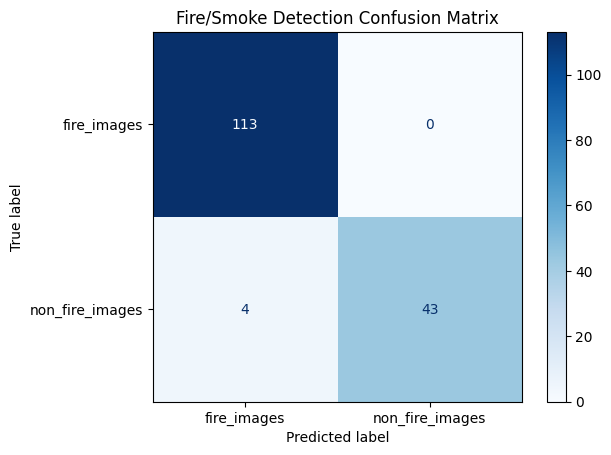

In [20]:
# Build your confusion matrix here

y_true_fire = []
y_pred_probs_fire = []

for images, labels in test_fire:
    preds = model_fire.predict(images, verbose=0)
    y_true_fire.extend(labels.numpy())
    y_pred_probs_fire.extend(preds.flatten())

y_pred_fire = [1 if p >= 0.5 else 0 for p in y_pred_probs_fire]

cm_fire = confusion_matrix(y_true_fire, y_pred_fire)
disp_fire = ConfusionMatrixDisplay(
    confusion_matrix=cm_fire, display_labels=class_names_fire
)
disp_fire.plot(cmap=plt.cm.Blues)
plt.title("Fire/Smoke Detection Confusion Matrix")
plt.show()

*Your answer:*
A False Negative is far more costly than a False Positive in the context of Fires as failing to respond to an actual fire can lead to devastating damages due to no/late response to the fire whereas a False Alarm from a False Positive is simply inconvenient and much less costly than missing a true fire. For this, we'd decrease the default decision threshold of 0.5 to something lower like 0.3 to decrease False Negatives and increase False Positives.



---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [21]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [22]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [23]:
# Preprocess the data here

train_sat = train_raw_sat.map(lambda x, y: (preprocess_input(x), y))
val_sat = val_raw_sat.map(lambda x, y: (preprocess_input(x), y))
test_sat = test_raw_sat.map(lambda x, y: (preprocess_input(x), y))

train_sat = train_sat.prefetch(buffer_size=autotune)
val_sat = val_sat.prefetch(buffer_size=autotune)
test_sat = test_sat.prefetch(buffer_size=autotune)

In [24]:
# Build your model here

base_model_sat = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)
base_model_sat.trainable = False

inputs_sat = tf.keras.Input(shape=(224, 224, 3))
x_sat = base_model_sat(inputs_sat, training=False)
x_sat = GlobalAveragePooling2D()(x_sat)
outputs_sat = Dense(10, activation="softmax")(x_sat)  # 10 output classes

model_sat = Model(inputs_sat, outputs_sat)

In [25]:
# Compile your model here

model_sat.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  # Since labels are integer encoded
    metrics=["accuracy"],
)

model_sat.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 2C — Train and Evaluate

In [27]:
# Train your model here

history_sat = model_sat.fit(
    train_sat,
    validation_data=val_sat,
    epochs=5,
)

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 1119s 2s/step - accuracy: 0.9077 - loss: 0.2849 - val_accuracy: 0.9324 - val_loss: 0.2162
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 1081s 2s/step - accuracy: 0.9370 - loss: 0.1875 - val_accuracy: 0.9373 - val_loss: 0.1905
Epoch 3/5
105/591 ━━━━━━━━━━━━━━━━━━━━ 11:38 1s/step - accuracy: 0.9485 - loss: 0.1571

KeyboardInterrupt: 

In [ ]:
# Report validation and test accuracy here

# The Validation Accuracy is 0.9373
# The Test Accuracy is 0.9486


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

In [28]:
# Build your confusion matrix here

y_true_sat = []
y_pred_sat = []

for images, labels in test_sat:
    preds = model_sat.predict(images, verbose=0)
    y_true_sat.extend(labels.numpy())
    y_pred_sat.extend(np.argmax(preds, axis=1))

cm_sat = confusion_matrix(y_true_sat, y_pred_sat)
fig, ax = plt.subplots(figsize=(10, 10))
disp_sat = ConfusionMatrixDisplay(
    confusion_matrix=cm_sat, display_labels=class_names_sat
)
disp_sat.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation="vertical")
plt.title("EuroSAT Confusion Matrix")
plt.show()

KeyboardInterrupt: 

*Your answer:*

Land-use classes with crops tend to be the most confused often such as HerbaceousVegetation and Pasture or PermanentCrop and Annual Crop as without fine details, it is difficult to distinguish completely between the two.


---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | 0.9568 | 0.9373
| Test Accuracy | 0.9943 | 0.9486

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*

1. The Fire Dataset was closer to ImageNet because the Fire image set contains ground-level/eye-level photographs much like how ImageNet is; this leads to much higher accuracy for MobileNetV2 on our Fire Image set due to this similarity. EuroSAT is the bigger mismatch because EuroSAT consists of top-down satellite photographs as opposed to ground level photographs leading to lower accuracy due to differing base models.

2. For the Fire Data set, we already have pretty high accuracy so our changes would be minimal that we could due, maybe to help accentuate generic features? For EuroSAT, we have room for improvement on the pretrained model since we could try to push the model to be able to handle the top-down perspective of satellite imagery better.


---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*

1. The Fire dataset composition was severely imbalanced initially. Fire images made up ~75.6% of the dataset and non-fire images made up only ~24.4% of the dataset. If we used regular train test splitting which is random, we could have a major imbalance of Fire and non-fire images in the train and test sets. It was imperative that we used stratified train-test split in order to ensure that the percentage of Fire and Non-Fire images remained the same in the train and test sets. Additionally, a confusion matrix is especially beneficial for examining false positives and false negatives.

2. For the Part 1 Output Layer, we used the sigmoid activation function and binary_crossentropy loss due to the binary classification of 2 classes and only requiring 1 output. For the Part 2 Output Layer, we used the softmax activation and sparce_categorical_crossentropy loss due to having 10 classes that required 10 outputs and needed discrete probabilities for each class.

3. A pretrained model's performance can vary due to how well its original training matches our task. The MobeileNetV2 was originally trained on eye-level imagery. Our First Task in the Fire dataset also contained eye-level imagery and lead to us having high accuracy whereas when we were on the Part 2 dataset which followed satellite imagery, we had lower performance and accuracy due to this difference in original base model. Adjusting the original model can help us to alleviate this difference if we have differing image styles in the future.

---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.